Mounted at /content/drive
Run: 20260306_173135
Rows: 100000
Notebook 02 completed


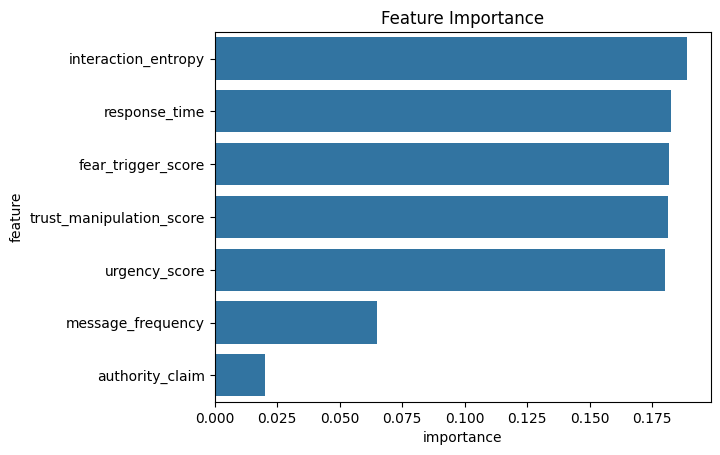

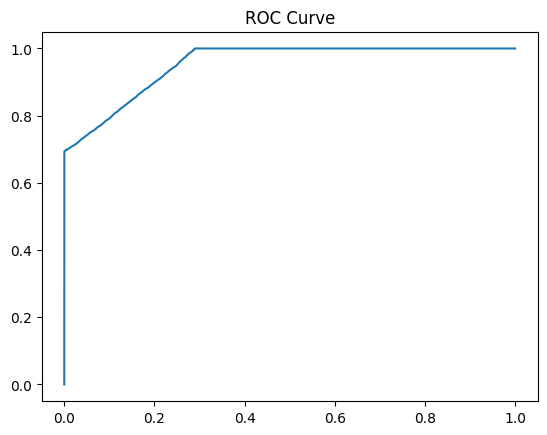

In [1]:
# ===============================================================
# NOTEBOOK 02 — COGNITIVE SIGNAL EXTRACTION
# CAT Framework Research Pipeline
# ===============================================================

!pip -q install pandas numpy torch scikit-learn seaborn matplotlib tqdm \
pyarrow transformers shap networkx omegaconf

import os
import json
import torch
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = ROOT / "runs" / RUN_ID
DATA_DIR = ROOT / "data"

REPORT_DIR = RUN_DIR / "reports"
MODEL_DIR = RUN_DIR / "models"
PLOT_DIR = RUN_DIR / "plots"

for p in [RUN_DIR, REPORT_DIR, MODEL_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Run:", RUN_ID)

# ===============================================================
# LOAD DATASET
# ===============================================================

DATA_PATH = DATA_DIR / "GCT_phase1_100k.parquet"

df = pd.read_parquet(DATA_PATH)

print("Rows:", len(df))

# ===============================================================
# VALIDATE COGNITIVE SIGNALS
# ===============================================================

signals = [
"urgency_score",
"fear_trigger_score",
"trust_manipulation_score",
"authority_claim"
]

range_check = df[signals].describe()

range_check.to_csv(REPORT_DIR/"signal_range_report.csv")

# ===============================================================
# CMS RECOMPUTATION
# ===============================================================

alpha = beta = gamma = delta = 0.25

df["CMS_recalc"] = (
alpha*df["urgency_score"] +
beta*df["fear_trigger_score"] +
gamma*df["authority_claim"] +
delta*df["trust_manipulation_score"]
)

cms_error = (df["CMS"] - df["CMS_recalc"]).abs().mean()

# ===============================================================
# TEXT FEATURE EXTRACTION
# ===============================================================

tfidf = TfidfVectorizer(max_features=3000)

X_text = tfidf.fit_transform(df["text_transcript"])

# ===============================================================
# COGNITIVE FEATURES
# ===============================================================

X_signals = df[
[
"urgency_score",
"fear_trigger_score",
"authority_claim",
"trust_manipulation_score",
"response_time",
"message_frequency",
"interaction_entropy"
]
]

# ===============================================================
# TARGET
# ===============================================================

y = df["human_verified_label"]

# ===============================================================
# TRAIN TEST SPLIT
# ===============================================================

X_train, X_test, y_train, y_test = train_test_split(
X_signals, y, stratify=y, test_size=0.2, random_state=42
)

# ===============================================================
# LOGISTIC REGRESSION BASELINE
# ===============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train_scaled, y_train)

pred = log_model.predict(X_test_scaled)

report = classification_report(y_test, pred, output_dict=True)

pd.DataFrame(report).to_csv(REPORT_DIR/"logistic_results.csv")

# ===============================================================
# RANDOM FOREST BASELINE
# ===============================================================

rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rf_report = classification_report(y_test, pred_rf, output_dict=True)

pd.DataFrame(rf_report).to_csv(REPORT_DIR/"rf_results.csv")

# ===============================================================
# FEATURE IMPORTANCE
# ===============================================================

imp = pd.DataFrame({
"feature":X_signals.columns,
"importance":rf.feature_importances_
}).sort_values("importance",ascending=False)

imp.to_csv(REPORT_DIR/"feature_importance_scores.csv")

plt.figure()

sns.barplot(data=imp,x="importance",y="feature")

plt.title("Feature Importance")

plt.savefig(PLOT_DIR/"feature_importance.png")

# ===============================================================
# ROC CURVE
# ===============================================================

proba = rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,proba)

plt.figure()

plt.plot(fpr,tpr)

plt.title("ROC Curve")

plt.savefig(PLOT_DIR/"roc_curve.png")

# ===============================================================
# CAT TENSOR ENGINE
# ===============================================================

class TrustTensor:

    r"""
    Trust Topology Tensor

    T_{ijk}

    i = user
    j = channel
    k = trust signal
    """

    def __init__(self,tensor):

        self.tensor = tensor

class CognitiveDistortionEnergy:

    r"""
    CDE = Σ ω_{ijk} T_{ijk}
    """

    def __init__(self,weights):

        self.weights = weights

    def __call__(self,T):

        return torch.einsum("ijk,ijk->",T.tensor,self.weights)

# ===============================================================
# GNN MESSAGE PASSING
# ===============================================================

class GraphWarpLayer:

    def __init__(self,in_dim,out_dim):

        self.W = torch.nn.Parameter(torch.randn(in_dim,out_dim))

    def __call__(self,H,A):

        return torch.einsum("ij,jk->ik",A,torch.einsum("ij,jk->ik",H,self.W))

# ===============================================================
# TRUST DISTORTION INDEX
# ===============================================================

class KalmanFilter:

    def __init__(self):

        self.x=1
        self.P=1
        self.Q=1e-5
        self.R=1e-2

    def update(self,z):

        K=self.P/(self.P+self.R)

        self.x=self.x+K*(z-self.x)

        self.P=(1-K)*self.P+self.Q

        return self.x

class TrustDistortionIndex:

    def __init__(self):

        self.filter=KalmanFilter()

    def __call__(self,cde,signals):

        var=torch.var(signals)

        smooth=self.filter.update(var.item())

        return cde/(smooth+1e-6)

# ===============================================================
# DEMO
# ===============================================================

users=64
channels=4
signals=8

T=torch.randn(users,channels,signals)

W=torch.randn(users,channels,signals)

tensor=TrustTensor(T)

cde_engine=CognitiveDistortionEnergy(W)

cde=cde_engine(tensor)

tdi_engine=TrustDistortionIndex()

tdi=tdi_engine(cde,torch.randn(1000))

# ===============================================================
# FINAL REPORT
# ===============================================================

report={
"rows":len(df),
"cms_error":float(cms_error),
"CDE_demo":float(cde.item()),
"TDI_demo":float(tdi.item())
}

with open(REPORT_DIR/"notebook02_report.json","w") as f:

    json.dump(report,f,indent=4)

print("Notebook 02 completed")